In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
drive_path = '/content/drive/Shareddrives/CMPE256_FinalProject/board_game_recommendation'

if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        item_path = os.path.join(drive_path, item)
        if os.path.isdir(item_path):
            print(f"[Folder] {item}")
        else:
            print(f"[File] {item}")
else:
    print(f"Error: Google Drive path '{drive_path}' not found. Please ensure Google Drive is mounted correctly.")

Contents of '/content/drive/Shareddrives/CMPE256_FinalProject/board_game_recommendation':
[Folder] raw_data
[Folder] data
[Folder] processed_data
[Folder] users
[File] eda.ipynb


In [4]:
# Define the path to the raw_data directory
raw_data_path = drive_path + '/raw_data'

# Dictionary to store the loaded Polars DataFrames
dataframes = {}

print(f"Loading data from: {raw_data_path}")
for item in os.listdir(raw_data_path):
    file_path = os.path.join(raw_data_path, item)
    if os.path.isfile(file_path):
        file_name_without_ext = os.path.splitext(item)[0]
        print(f"Processing file: {item}")

        if item.endswith('.csv'):
            df = pl.read_csv(file_path)
            dataframes[file_name_without_ext] = df
            print(f"  Loaded '{file_name_without_ext}' with {df.shape[0]} rows and {df.shape[1]} columns.")
        else:
            print(f"Skipping unsupported file type: {item}")


# To list all loaded dataframes:
print(f"\nSuccessfully loaded {len(dataframes)} Polars DataFrames:")
for name, df in dataframes.items():
    print(f"  - {name}: Shape {df.shape}")

Loading data from: /content/drive/Shareddrives/CMPE256_FinalProject/board_game_recommendation/raw_data
Processing file: artists_reduced.csv
  Loaded 'artists_reduced' with 21925 rows and 1681 columns.
Processing file: designers_reduced.csv
  Loaded 'designers_reduced' with 21925 rows and 1594 columns.
Processing file: games.csv
  Loaded 'games' with 21925 rows and 48 columns.
Processing file: mechanics.csv
  Loaded 'mechanics' with 21925 rows and 158 columns.
Processing file: publishers_reduced.csv
  Loaded 'publishers_reduced' with 21925 rows and 1866 columns.
Processing file: ratings_distribution.csv
  Loaded 'ratings_distribution' with 21925 rows and 96 columns.
Processing file: themes.csv
  Loaded 'themes' with 21925 rows and 218 columns.
Processing file: user_ratings.csv
  Loaded 'user_ratings' with 18942215 rows and 3 columns.
Processing file: bgg_data_documentation.txt
Skipping unsupported file type: bgg_data_documentation.txt
Processing file: subcategories.csv
  Loaded 'subcate

In [5]:
dataframes['user_ratings'].head()

BGGId,Rating,Username
i64,f64,str
213788,8.0,"""Tonydorrf"""
213788,8.0,"""tachyon14k"""
213788,8.0,"""Ungotter"""
213788,8.0,"""brainlocki3"""
213788,8.0,"""PPMP"""


In [6]:
def check_quality(name, df):
    null_counts = df.null_count()
    total_rows = df.height
    print(f"\n--- Quality Report: {name} ---")
    print(f"Total Rows: {total_rows}")

    # Identify columns with nulls
    for col in df.columns:
        nulls = null_counts[col][0]
        if nulls > 0:
            print(f"Column '{col}': {nulls} nulls ({nulls/total_rows:.2%})")


In [7]:
# Check the main files
check_quality('games', dataframes['games'])
check_quality('user_ratings', dataframes['user_ratings'])

# Check for duplicate ratings (same user, same game)
duplicates = dataframes['user_ratings'].filter(
    dataframes['user_ratings'].select(['BGGId', 'Username']).is_duplicated()
).height
print(f"\nDuplicate User-Item pairs in ratings: {duplicates}")


--- Quality Report: games ---
Total Rows: 21925
Column 'Description': 1 nulls (0.00%)
Column 'ComAgeRec': 5530 nulls (25.22%)
Column 'LanguageEase': 5891 nulls (26.87%)
Column 'Family': 15262 nulls (69.61%)
Column 'ImagePath': 17 nulls (0.08%)

--- Quality Report: user_ratings ---
Total Rows: 18942215

Duplicate User-Item pairs in ratings: 64120


In [8]:
ratings = dataframes['user_ratings']
games = dataframes['games']
num_ratings = ratings.height
num_users = ratings['Username'].n_unique()
num_items = ratings['BGGId'].n_unique()

In [9]:
# Calculate Sparsity
# Formula: 1 - (Actual Ratings / Possible Ratings)
possible_ratings = num_users * num_items
sparsity = 1 - (num_ratings / possible_ratings)

print(f"--- Recommender System Statistics ---")
print(f"Unique Users: {num_users:,}")
print(f"Unique Items: {num_items:,}")
print(f"Total Ratings: {num_ratings:,}")
print(f"Matrix Sparsity: {sparsity:.6%}")


--- Recommender System Statistics ---
Unique Users: 411,375
Unique Items: 21,925
Total Ratings: 18,942,215
Matrix Sparsity: 99.789984%


In [10]:
# Cold-Start Characteristics
# Users with very few ratings (e.g., < 5)
user_counts = ratings.group_by('Username').count()
cold_start_users = user_counts.filter(pl.col('count') < 5).height

# Items with very few ratings
item_counts = ratings.group_by('BGGId').count()
cold_start_items = item_counts.filter(pl.col('count') < 5).height

print(f"\nCold-Start Users (<5 ratings): {cold_start_users} ({cold_start_users/num_users:.2%})")
print(f"Cold-Start Items (<5 ratings): {cold_start_items} ({cold_start_items/num_items:.2%})")

/tmp/ipykernel_2428/1226621923.py:3: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  user_counts = ratings.group_by('Username').count()
/tmp/ipykernel_2428/1226621923.py:7: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  item_counts = ratings.group_by('BGGId').count()



Cold-Start Users (<5 ratings): 139190 (33.84%)
Cold-Start Items (<5 ratings): 0 (0.00%)


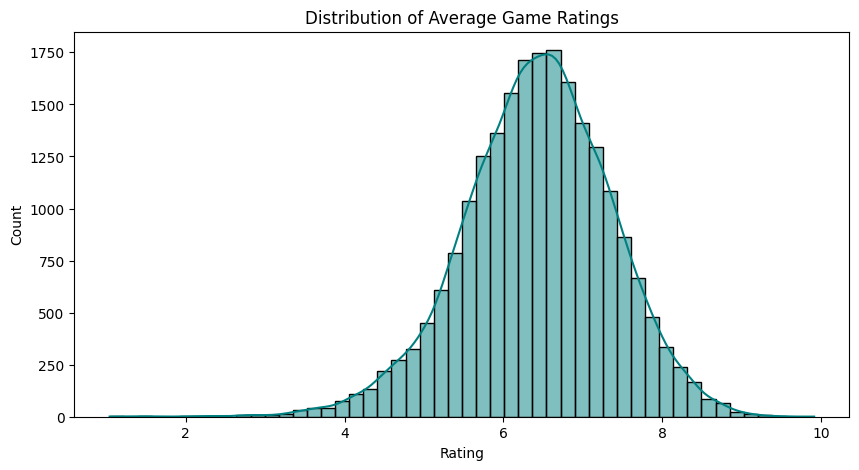

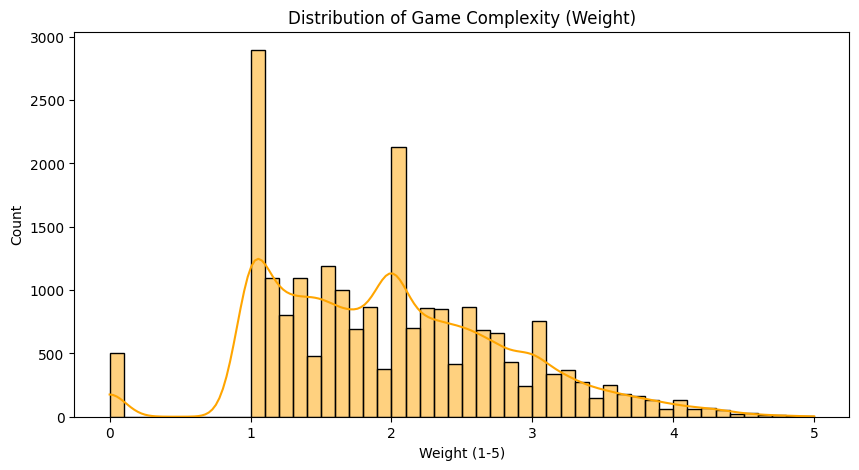

In [13]:
# Distribution of Average Ratings in the Games metadata
plt.figure(figsize=(10, 5))
sns.histplot(dataframes['games']['AvgRating'].to_numpy(), bins=50, kde=True, color='teal')
plt.title('Distribution of Average Game Ratings')
plt.xlabel('Rating')
plt.show()

# Distribution of 'Weight' (Complexity)
plt.figure(figsize=(10, 5))
sns.histplot(dataframes['games']['GameWeight'].to_numpy(), bins=50, kde=True, color='orange')
plt.title('Distribution of Game Complexity (Weight)')
plt.xlabel('Weight (1-5)')
plt.show()

In [14]:
def plot_top_binary_features(name, df, top_n=15):
    # Exclude the ID column and sum the binary flags
    feature_cols = [c for c in df.columns if c != 'BGGId']
    counts = df.select([pl.col(c).sum() for c in feature_cols]).transpose(include_header=True)
    counts.columns = ['Feature', 'Count']
    top_features = counts.sort('Count', descending=True).head(top_n)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='Count', y='Feature', data=top_features.to_pandas())
    plt.title(f'Top {top_n} {name}')
    plt.show()

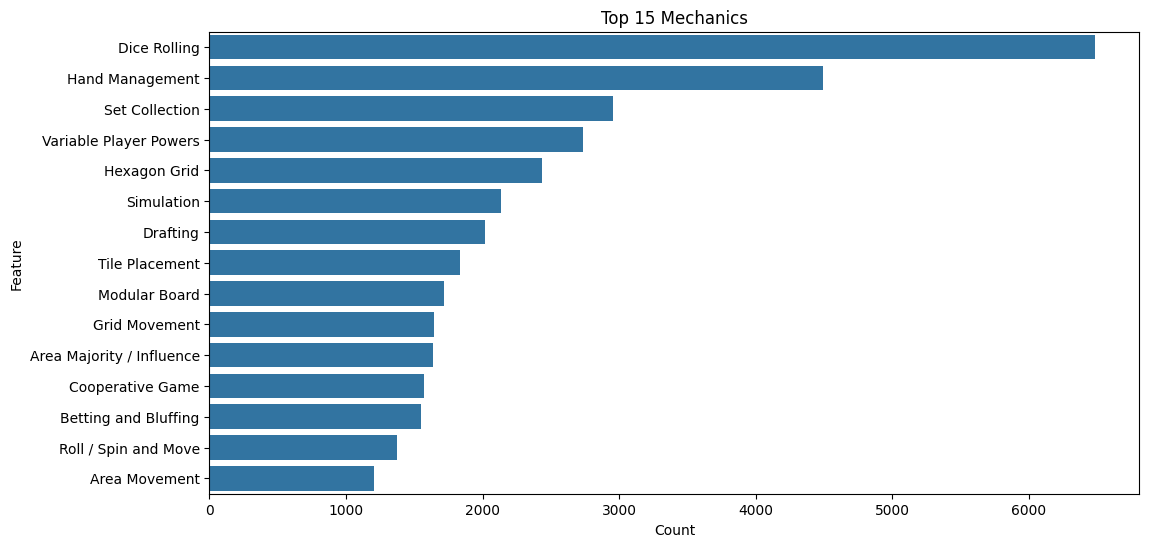

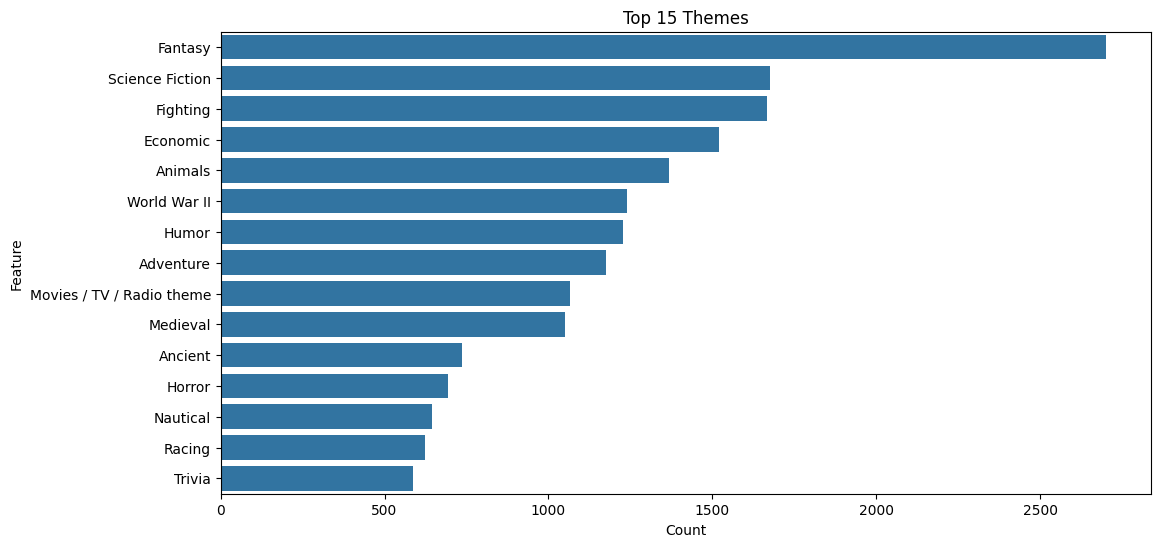

In [15]:
plot_top_binary_features('Mechanics', dataframes['mechanics'])
plot_top_binary_features('Themes', dataframes['themes'])

In [16]:
# Deduplicate: Group by User/Game and take the average rating
ratings_clean = dataframes['user_ratings'].group_by(['Username', 'BGGId']).agg(
    pl.col('Rating').mean().alias('Rating')
)

print(f"Original ratings: {dataframes['user_ratings'].height:,}")
print(f"Cleaned ratings: {ratings_clean.height:,}")
print(f"Removed {dataframes['user_ratings'].height - ratings_clean.height:,} duplicates.")

Original ratings: 18,942,215
Cleaned ratings: 18,909,528
Removed 32,687 duplicates.


In [17]:
# Impute missing metadata
games_clean = dataframes['games'].with_columns([
    # 1. Fill Community Age with Manufacturer Age where missing
    pl.col("ComAgeRec").fill_null(pl.col("MfgAgeRec")),

    # 2. Fill LanguageEase with the median (conservative estimate)
    pl.col("LanguageEase").fill_null(pl.col("LanguageEase").median()),

    # 3. Fill the single missing Description
    pl.col("Description").fill_null("No description available")
])

# Final check for remaining nulls in critical columns
print(f"Remaining nulls in ComAgeRec: {games_clean['ComAgeRec'].null_count()}")

Remaining nulls in ComAgeRec: 0


In [18]:
# 1. Identify valid users (count >= 5)
user_activity = ratings_clean.group_by("Username").len()
valid_usernames = user_activity.filter(pl.col("len") >= 5).select("Username")

# 2. Identify valid games (count >= 10)
# Note: EDA showed 0 items < 5, but 10 is a safer threshold for item-means
item_activity = ratings_clean.group_by("BGGId").len()
valid_bggids = item_activity.filter(pl.col("len") >= 10).select("BGGId")

# 3. Filter the ratings table
ratings_filtered = ratings_clean.join(valid_usernames, on="Username").join(valid_bggids, on="BGGId")

print(f"Post-Filtering Stats:")
print(f" - Ratings remaining: {ratings_filtered.height:,}")
print(f" - Users remaining: {ratings_filtered['Username'].n_unique():,}")
print(f" - Games remaining: {ratings_filtered['BGGId'].n_unique():,}")

Post-Filtering Stats:
 - Ratings remaining: 18,663,696
 - Users remaining: 272,136
 - Games remaining: 21,924


In [20]:
# 1. Create User Mapping
unique_users = ratings_clean.select("Username").unique().sort("Username")
user_mapping = unique_users.with_row_index(name="user_id")

# 2. Create Item Mapping (Based on the Games table to ensure metadata alignment)
unique_items = games_clean.select("BGGId").unique().sort("BGGId")
item_mapping = unique_items.with_row_index(name="item_id")

# 3. Join mappings back to the main tables
ratings_final = ratings_clean.join(user_mapping, on="Username").join(item_mapping, on="BGGId")
games_final = games_clean.join(item_mapping, on="BGGId")

print(f"Mapped {user_mapping.height:,} users and {item_mapping.height:,} items.")

Mapped 411,375 users and 21,925 items.


In [21]:
# Combine metadata into a single "Master Item" table
items_final = games_final.join(dataframes['mechanics'], on="BGGId", how="left") \
                         .join(dataframes['themes'], on="BGGId", how="left")

In [22]:
# Normalization helper to prevent code repetition
def min_max_scale(df, col_name):
    col_min = df[col_name].min()
    col_max = df[col_name].max()
    return (pl.col(col_name) - col_min) / (col_max - col_min)

items_normalized = items_final.with_columns([
    min_max_scale(items_final, "YearPublished").alias("YearPublished_norm"),
    min_max_scale(items_final, "GameWeight").alias("GameWeight_norm")
])

# Filter metadata to match only the games remaining after long-tail filtering
items_filtered = items_normalized.join(valid_bggids, on="BGGId")

Comparison

In [24]:
# --- BEFORE STATS (using ratings_clean from deduplication step) ---
b_rows = ratings_clean.height
b_users = ratings_clean['Username'].n_unique()
b_items = ratings_clean['BGGId'].n_unique()
b_sparsity = 1 - (b_rows / (b_users * b_items))

# --- AFTER STATS (using ratings_filtered from filtering step) ---
a_rows = ratings_filtered.height
a_users = ratings_filtered['Username'].n_unique()
a_items = ratings_filtered['BGGId'].n_unique()
a_sparsity = 1 - (a_rows / (a_users * a_items))

# --- CALCULATION OF PERCENTS IGNORED ---
row_diff = b_rows - a_rows
user_diff = b_users - a_users
item_diff = b_items - a_items

print("="*50)
print("DATA PREPROCESSING: BEFORE VS AFTER STATS")
print("="*50)

print(f"{'Metric':<20} | {'Before':<12} | {'After':<12} | {'% Reduced':<10}")
print("-" * 65)
print(f"{'Total Ratings':<20} | {b_rows:<12,} | {a_rows:<12,} | {row_diff/b_rows:.2%}")
print(f"{'Unique Users':<20} | {b_users:<12,} | {a_users:<12,} | {user_diff/b_users:.2%}")
print(f"{'Unique Items':<20} | {b_items:<12,} | {a_items:<12,} | {item_diff/b_items:.2%}")
print(f"{'Matrix Sparsity':<20} | {b_sparsity:<12.5%} | {a_sparsity:<12.5%} | N/A")


DATA PREPROCESSING: BEFORE VS AFTER STATS
Metric               | Before       | After        | % Reduced 
-----------------------------------------------------------------
Total Ratings        | 18,909,528   | 18,663,696   | 1.30%
Unique Users         | 411,375      | 272,136      | 33.85%
Unique Items         | 21,925       | 21,924       | 0.00%
Matrix Sparsity      | 99.79035%    | 99.68718%    | N/A


Export

In [25]:
# Define export paths (Shared Google Drive)
processed_dir = drive_path + '/processed_data'
os.makedirs(processed_dir, exist_ok=True)

In [26]:
# Export to Parquet
ratings_final.write_parquet(f"{processed_dir}/ratings_final.parquet")
items_final.write_parquet(f"{processed_dir}/items_metadata_final.parquet")
user_mapping.write_parquet(f"{processed_dir}/user_mapping.parquet")

print(f"data saved to {processed_dir}")

data saved to /content/drive/Shareddrives/CMPE256_FinalProject/board_game_recommendation/processed_data


In [27]:
#CSV Backups
csv_backup_dir = drive_path + '/processed_data/csv_backups'
os.makedirs(csv_backup_dir, exist_ok=True)

ratings_final.write_csv(f"{csv_backup_dir}/ratings_final.csv")
items_final.write_csv(f"{csv_backup_dir}/items_metadata_final.csv")
user_mapping.write_csv(f"{csv_backup_dir}/user_mapping.csv")
item_mapping.write_csv(f"{csv_backup_dir}/item_mapping.csv")

In [28]:
print("hi")

hi


# Splitting the data

In [29]:
# 1. Shuffle the entire dataset to ensure randomness within user groups
# Seed 42 ensures the split is reproducible for all team members
ratings_shuffled = ratings_final.sample(fraction=1.0, shuffle=True, seed=42)


In [30]:

# 2. Assign a cumulative count per user to determine the split position
ratings_with_index = ratings_shuffled.with_columns([
    pl.col("user_id").cum_count().over("user_id").alias("rating_index"),
    pl.col("user_id").count().over("user_id").alias("user_total_ratings")
])



In [31]:
# 3. Apply the 80/10/10 logic
# 0.0 to 0.8 -> Train | 0.8 to 0.9 -> Val | 0.9 to 1.0 -> Test
ratings_split = ratings_with_index.with_columns(
    pl.when(pl.col("rating_index") <= (pl.col("user_total_ratings") * 0.8))
    .then(pl.lit("train"))
    .when(pl.col("rating_index") <= (pl.col("user_total_ratings") * 0.9))
    .then(pl.lit("val"))
    .otherwise(pl.lit("test"))
    .alias("split")
)

In [32]:
# 4. Separate into final dataframes
train_df = ratings_split.filter(pl.col("split") == "train").drop(["rating_index", "user_total_ratings"])
val_df = ratings_split.filter(pl.col("split") == "val").drop(["rating_index", "user_total_ratings"])
test_df = ratings_split.filter(pl.col("split") == "test").drop(["rating_index", "user_total_ratings"])

print(f"Split Summary:")
print(f" - Train: {train_df.height:,} rows ({train_df.height/ratings_split.height:.1%})")
print(f" - Val:   {val_df.height:,} rows ({val_df.height/ratings_split.height:.1%})")
print(f" - Test:  {test_df.height:,} rows ({test_df.height/ratings_split.height:.1%})")

# 5. Store the final datasets for Phase 2 consumption
split_dir = drive_path + '/processed_data/final_foundation/splits'
os.makedirs(split_dir, exist_ok=True)

train_df.write_parquet(f"{split_dir}/train.parquet")
val_df.write_parquet(f"{split_dir}/val.parquet")
test_df.write_parquet(f"{split_dir}/test.parquet")

print(f"\n All splits saved to: {split_dir}")

Split Summary:
 - Train: 14,929,223 rows (79.0%)
 - Val:   1,856,255 rows (9.8%)
 - Test:  2,124,050 rows (11.2%)

 All splits saved to: /content/drive/Shareddrives/CMPE256_FinalProject/board_game_recommendation/processed_data/final_foundation/splits
